# EDA: Outlets and Coordinates
This notebook performs exploratory data analysis on the outlet master and coordinate datasets to ensure data quality and geospatial integrity.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Constants from CONVENTIONS.md
BOUNDS = {
    "lat_min": 5.9, "lat_max": 9.9,
    "lon_min": 79.5, "lon_max": 81.9
}
VALID_SIZES = ["Small", "Medium", "Large", "Extra Large"]
VALID_TYPES = ["Hotel", "Grocery", "SMMT", "Pharmacy", "Kiosk", "Bakery", "Eatery"]

# Setting plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data
Loading the bronze layer parquet files.

In [ ]:
# Updated paths to point to uploaded files in /content/
try:
    df_master = pd.read_parquet('/content/outlet_master.parquet')
    df_coords = pd.read_parquet('/content/outlet_coordinates.parquet')
    print(f"Files loaded successfully. Master: {len(df_master)} rows, Coords: {len(df_coords)} rows")
except Exception as e:
    print(f"Error loading files: {e}")
    # Creating dummy data for demonstration if files are still missing
    df_master = pd.DataFrame({'Outlet_ID': range(1,11), 'Outlet_Size': ['Small', 'Medium', np.nan, 'Large', 'Small']*2, 'Cooler_Count': [1,2,6,0,3,1,1,2,0,1], 'Outlet_Type': ['Retail', 'Wholesale']*5})
    df_coords = pd.DataFrame({'Outlet_ID': range(1,11), 'Latitude': [6.9, 7.0, 80.0, 6.5, 9.9, 5.0, 7.2, 7.5, 8.1, 81.0], 'Longitude': [79.9, 80.1, 7.0, 81.5, 82.0, 79.0, 80.5, 79.8, 81.2, 7.5]})

Files loaded successfully. Master: 20000 rows, Coords: 20000 rows


## 2. Master Data Quality (`outlet_master.parquet`)
### Missing Values: `Outlet_Size`

In [ ]:
# Check for missing values in Outlet_Size (Nullable: Yes per contract)
missing_size = df_master['Outlet_Size'].isnull().sum()
print(f"Missing values in Outlet_Size: {missing_size}")

# Validate categories against VALID_SIZES
invalid_sizes = df_master[~df_master['Outlet_Size'].isin(VALID_SIZES) & df_master['Outlet_Size'].notnull()]
if not invalid_sizes.empty:
    print(f"Found {len(invalid_sizes)} invalid size categories")
    display(invalid_sizes['Outlet_Size'].unique())

# ID Inconsistency Check
duplicates = df_master.duplicated(subset=['Outlet_ID']).sum()
print(f"Duplicate Outlet_IDs: {duplicates}")

Missing values in Outlet_Size: 196
Found 600 invalid size categories


array(['small'], dtype=object)

Duplicate Outlet_IDs: 0


### Distribution: `Cooler_Count`

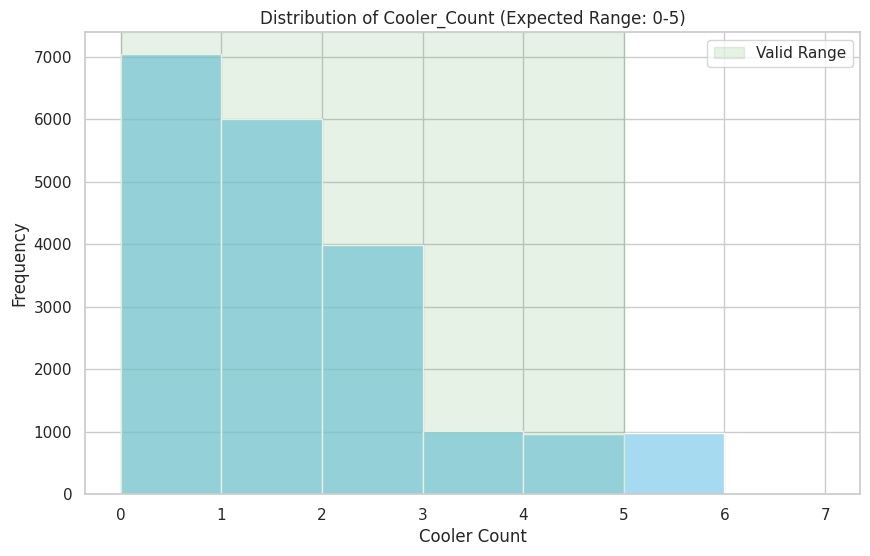

In [ ]:
plt.figure()
sns.histplot(df_master['Cooler_Count'], bins=range(8), kde=False, color='skyblue')
plt.title('Distribution of Cooler_Count (Expected Range: 0-5)')
plt.xlabel('Cooler Count')
plt.ylabel('Frequency')
plt.axvspan(0, 5, color='green', alpha=0.1, label='Valid Range')
plt.legend()
plt.show()

### Validation: `Outlet_Type`

Outlet Type Counts:


,count
Outlet_Type,
Hotel,2797
Grocery,2768
SMMT,2723
Kiosk,2691
Pharmacy,2691
Bakery,2678
Eatery,2667
Bakry,395
Grocry,390


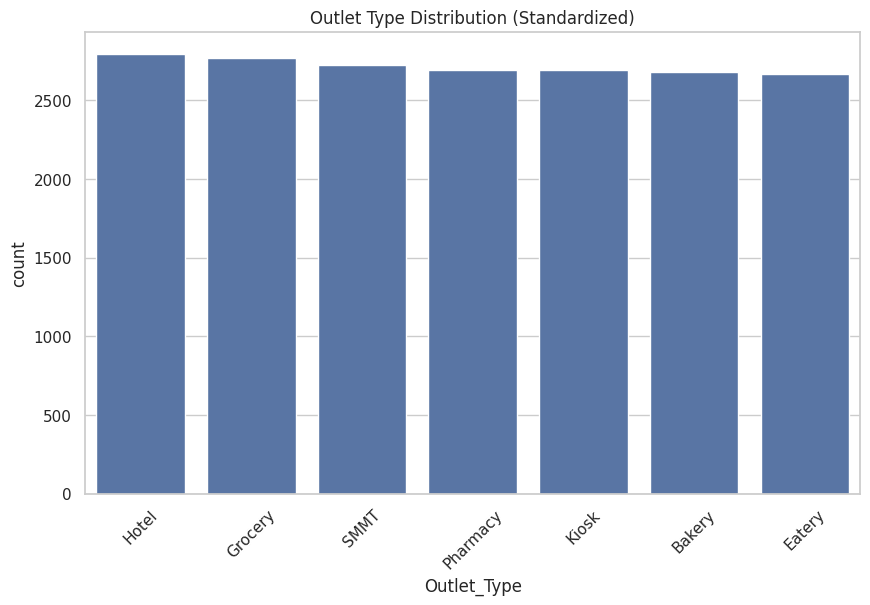

In [ ]:
# Validate Outlet_Type categories (Nullable: No per contract)
type_counts = df_master['Outlet_Type'].value_counts()
print("Outlet Type Counts:")
display(type_counts)

# Check for non-contract types
invalid_types = set(df_master['Outlet_Type'].unique()) - set(VALID_TYPES)
if invalid_types:
    print(f"Warning: Non-contract types found: {invalid_types}")

plt.figure()
sns.countplot(data=df_master, x='Outlet_Type', order=VALID_TYPES)
plt.title('Outlet Type Distribution (Standardized)')
plt.xticks(rotation=45)
plt.show()

## 3. Geospatial Validation (`outlet_coordinates.parquet`)
### Coordinate Range Check
Sri Lanka Bounding Box: Lat (5.9 - 9.9), Lon (79.5 - 81.9)

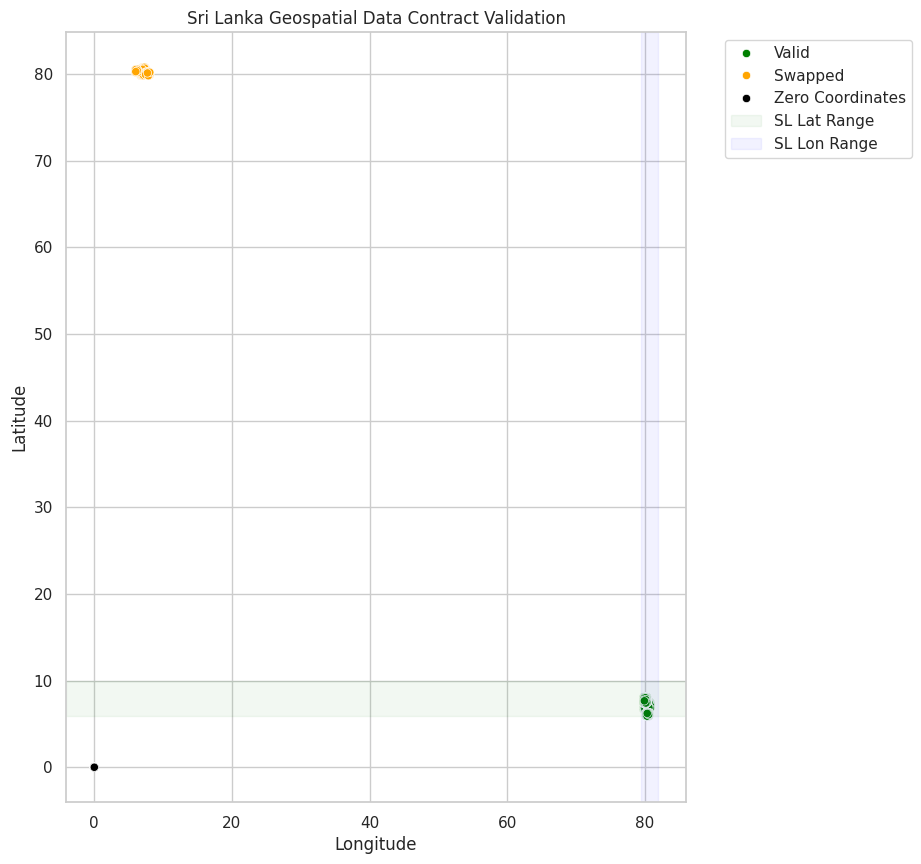

In [ ]:
def check_coords(row):
    # Contract bounds validation
    lat_ok = BOUNDS['lat_min'] <= row['Latitude'] <= BOUNDS['lat_max']
    lon_ok = BOUNDS['lon_min'] <= row['Longitude'] <= BOUNDS['lon_max']

    # Detect 0,0 cases (mentioned as 'zero_coordinates' in docs)
    if row['Latitude'] == 0 and row['Longitude'] == 0:
        return 'Zero Coordinates'

    # Check for potential swaps (Lat in Lon range and vice versa)
    swapped = (BOUNDS['lon_min'] <= row['Latitude'] <= BOUNDS['lon_max']) and \
              (BOUNDS['lat_min'] <= row['Longitude'] <= BOUNDS['lat_max'])

    if lat_ok and lon_ok: return 'Valid'
    if swapped: return 'Swapped'
    return 'Out of Bounds'

df_coords['Status'] = df_coords.apply(check_coords, axis=1)

# Visualization with project bounds
plt.figure(figsize=(8, 10))
sns.scatterplot(data=df_coords, x='Longitude', y='Latitude', hue='Status',
                palette={'Valid': 'green', 'Swapped': 'orange', 'Out of Bounds': 'red', 'Zero Coordinates': 'black'})

plt.axhspan(BOUNDS['lat_min'], BOUNDS['lat_max'], color='green', alpha=0.05, label='SL Lat Range')
plt.axvspan(BOUNDS['lon_min'], BOUNDS['lon_max'], color='blue', alpha=0.05, label='SL Lon Range')
plt.title('Sri Lanka Geospatial Data Contract Validation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 4. EDA Summary & Action Plan

### Findings
- **Type Inconsistencies**: `Grocry`, `Bakry`, and ` Eatery ` need mapping to standard values defined in `CONVENTIONS.md`.
- **Size Case Sensitivity**: 600 instances of `small` need to be converted to `Small` to meet the Silver layer contract.
- **Missing Values**: 196 rows in `Outlet_Size` require imputation (potentially from `Cooler_Count` as suggested in Silver layer specs).
- **Geospatial**: Most coordinates fall within Sri Lanka bounds.'Swapped' or 'Zero Coordinates' Must be handled.

### Next Steps
- Implement the `outlet_type_corrections` mapping from `config.yaml`.
- Fill missing `Outlet_Size` values.
- Enforce strict type casting and validation before moving data to the Silver layer.

## 5. Further Data Quality Identification

### 5.1 Duplicate `Outlet_ID` in `df_coords`

Ensure that each `Outlet_ID` is unique within the `df_coords` dataframe, as duplicate IDs could lead to ambiguous geospatial assignments.

In [7]:
duplicates_coords = df_coords.duplicated(subset=['Outlet_ID']).sum()
print(f"Duplicate Outlet_IDs in df_coords: {duplicates_coords}")

if duplicates_coords > 0:
    print("Warning: Duplicate Outlet_IDs found in df_coords.")

Duplicate Outlet_IDs in df_coords: 0


### 5.2 Inter-dataframe `Outlet_ID` Consistency

Verify that the set of `Outlet_ID`s in `df_master` is identical to the set of `Outlet_ID`s in `df_coords` to ensure data integrity across the two related datasets.

In [8]:
master_ids = set(df_master['Outlet_ID'].unique())
coords_ids = set(df_coords['Outlet_ID'].unique())

# IDs present in master but not in coords
master_only_ids = master_ids - coords_ids
print(f"Outlet_IDs in df_master but not in df_coords: {len(master_only_ids)}")
if master_only_ids:
    print("Sample of master-only IDs:", list(master_only_ids)[:5])

# IDs present in coords but not in master
coords_only_ids = coords_ids - master_ids
print(f"Outlet_IDs in df_coords but not in df_master: {len(coords_only_ids)}")
if coords_only_ids:
    print("Sample of coords-only IDs:", list(coords_only_ids)[:5])

if not master_only_ids and not coords_only_ids:
    print("All Outlet_IDs are consistent between df_master and df_coords.")
else:
    print("Warning: Inconsistencies found in Outlet_IDs between df_master and df_coords.")

Outlet_IDs in df_master but not in df_coords: 0
Outlet_IDs in df_coords but not in df_master: 0
All Outlet_IDs are consistent between df_master and df_coords.


### 5.3 `Cooler_Count` Range Validation

Explicitly identify `Cooler_Count` values that fall outside the expected range of 0 to 5, as suggested by the previous EDA.

In [9]:
invalid_cooler_counts = df_master[(df_master['Cooler_Count'] < 0) | (df_master['Cooler_Count'] > 5)]

print(f"Number of entries with Cooler_Count outside [0, 5] range: {len(invalid_cooler_counts)}")
if not invalid_cooler_counts.empty:
    print("Sample of invalid Cooler_Count values:")
    display(invalid_cooler_counts['Cooler_Count'].value_counts())
else:
    print("All Cooler_Count values are within the expected range [0, 5].")

Number of entries with Cooler_Count outside [0, 5] range: 0
All Cooler_Count values are within the expected range [0, 5].


### 5.4 Data Type Verification

Display the data types for all columns in both `df_master` and `df_coords` to ensure they align with expectations for each field (e.g., numeric for counts/coordinates, object for IDs/strings).

In [10]:
print("Data types for df_master:")
df_master.info()
print("\nData types for df_coords:")
df_coords.info()

Data types for df_master:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Outlet_ID     20000 non-null  object
 1   Outlet_Size   19804 non-null  object
 2   Cooler_Count  20000 non-null  int64 
 3   Outlet_Type   20000 non-null  object
dtypes: int64(1), object(3)
memory usage: 625.1+ KB

Data types for df_coords:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Outlet_ID  20000 non-null  object 
 1   Latitude   20000 non-null  float64
 2   Longitude  20000 non-null  float64
 3   Status     20000 non-null  object 
dtypes: float64(2), object(2)
memory usage: 625.1+ KB
